<h2 style="color: blue", text align='center';> ISAT 341: Machine Learning and Data Science    
    
<h3 style="color: green", text align='center';>Project: Machine Learning Confidential Sensor Data

<br>
    
<img src="images/machine_learning.jpg" width=200; height=200>   
    
<h2 style="color:red",text align='center'>  Working with <em>real-world</em> datasets </h2>

<h2 <b>Objectives</b> </h2>

To demonstrate the ability to complete an end-to-end data science / machine learning project using real-world data by following and
implementing the main machine learning checklist steps that lead to a solution, namely:

- Frame the problem and look at the big picture.
- Get the data.
- Explore the data to gain insights.
- Prepare the data to expose the underlying data patterns to Machine Learning algorithms.
- Explore many different models and short-list the best ones.
- Fine-tune your models and combine them into a great solution.
- Present your solution.
- Launch, monitor, and maintain your system

### <font color='purple'/> Frame the Problem

<img src="images/sensor_array.jpg" width="300" height="300" style="float:right;">


<b>Sensor Data </b>

The data source as well as the exact nature of the data is confidential. Each data instance contains 12 real-valued input attributes. Each input attribute represents a sensor designed to detect the presence of one of two groups of substances. As an alternative, the sensor readings may represent a 'false alarm'.

- Substance 1 is represented by the value 'one' in the class attribute column.
- Substance 2 is represented by the value 'two' in the class attribute column.
- A false alarm is represented by the value 'three' in the class attribute column.

The problem is framed as a <b>supervised learning</b> problem: Predict the class of a substance from sensor data using the given measurements in the dataset.





<br>






</br>


<center>
    <h3><font color='purple'>Project Analysis Starts Here!</font></h3>
</center>

In [1]:
# import packages
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
np.set_printoptions(precision=3,suppress=True)

### <font color='green'/> Exploratory Data Analysis

<b> 1) TO DO: Use Pandas to load your data into a data frame</b>
<br>

</br>
Display the first ten rows after you load the data

In [2]:
# Import CSV file 
df = pd.read_csv('Data/Sensor_Data_Confidential_341Project_DataSet7.csv', encoding='utf')
# Displaying the first 10 rows of data
df.head(10)

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Input 9,Input 10,Input 11,Input 12,class
0,4.406,0.6116,5.691,5.906,1.763,2.726,0.9607,0.6055,1.859,5.083,5.503,0.7544,one
1,4.680,0.5322,5.461,5.923,1.589,2.799,0.9937,0.6250,1.821,5.099,5.601,0.9546,one
2,4.738,0.5298,5.680,5.916,1.844,2.798,1.0280,0.6238,1.759,5.127,5.535,0.7275,one
3,4.503,0.5273,5.703,-9999.000,1.711,2.856,1.1500,0.6201,1.736,5.094,5.452,0.7690,one
4,4.744,0.5884,5.532,5.911,1.792,2.886,1.0310,0.5627,1.868,4.989,5.382,0.6665,one
5,4.524,0.6311,5.773,5.822,1.803,2.800,1.0490,0.6836,1.885,5.100,5.479,0.6958,one
6,4.570,0.4834,5.804,5.887,1.708,2.894,1.0830,0.4919,1.807,5.062,5.336,0.8447,one
7,4.489,0.5054,5.790,5.900,1.849,2.919,0.9082,0.6055,1.809,5.216,5.555,0.6897,one
8,4.503,0.6091,5.686,5.892,1.714,2.822,1.0300,0.6079,1.840,5.001,5.360,0.9521,one
9,4.425,0.6091,5.732,5.912,1.793,2.726,1.0950,0.6104,1.749,5.020,5.514,0.8081,one


<b> 2) TO DO: Use the dataframe describe method <em> dataframe.describe()</em> to display some summary statistics</b>

In [3]:
# using dataframe.describe() method
df.describe()

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Input 9,Input 10,Input 11,Input 12
count,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000,1666.000000
mean,-134.420804,-118.114677,-109.102194,-91.399119,-125.040359,-130.537302,-77.319851,-125.663162,-95.131987,-75.160382,-88.122777,-63.045762
std,1167.492978,1089.498394,1062.557232,975.926752,1115.959694,1141.932576,880.138338,1115.889116,975.558523,880.331222,944.963450,810.287385
min,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
25%,3.018500,0.820300,4.783250,3.479500,0.408900,0.600275,0.278300,0.181900,0.394000,1.420000,1.130000,0.764200
50%,4.073000,1.522500,5.340500,5.094500,0.795300,1.578000,0.523100,0.300300,0.728750,2.192000,1.345000,1.029000
75%,4.508000,3.122250,5.599000,5.649000,1.461250,2.177750,0.965600,0.504475,1.233000,4.968000,1.907500,5.337750
max,5.105000,4.675000,5.944000,6.011000,2.571000,3.638000,2.446000,1.199000,2.278000,5.312000,5.640000,5.825000


### <font color='purple'/> Comments on above summary of data

*Examine the data and note that when a sensor temporarily goes offline, it records a BAD data value of -9999.* This can be seen in the minimum
recorded values for each sensor. Before we continue our preliminary data analysis, this bad data must be removed.

You should also take note of the **count, mean, standard deviation** and the **maximum** data values for each sensor. The bad data value recordings when the senors go *offline* have a large impact on these simple descriptive statistical summaries. Also, the wide range of the data
values will require some sort of scaling of the data before training a machine learing model.

Finally, the class labels are not numeric but are strings ('one', 'two' and 'three') that we call categorical class labels. We will need to convert
them to integers before we feed them to a classifier.




### <font color='green'/> Data Cleansing

<b> 3) TO DO: Display the shape of your dataframe data in the cell below</b>


In [4]:
# printing the shape of data (X and y variables)
print('Shape of the DataFrame:{}'.format(df.shape))


Shape of the DataFrame:(1666, 13)


<b> 4) TO DO: Use Pandas dataframe to find bad or missing data</b>
<br>

</br>

The bad data can be located and replaced using pandas and numpy. In the cell below, use code to find and replace the bad data (-9999 values) with numpy nan values (nan means *not a number*). Then use the dataframe to drop the rows with the nan signatures. This may significantly reduce your dataset size so you should display the shape of the data to see its new size. Also, again, display the first ten rows of the data with the dataframe.
- <b>Enter your code in the cell below to implement the drop, replace and display.</b> 
- <b>Enter your code in the cell immediately following the output of the dataframe display to show the new shape of data in the dataframe.</b>

In [5]:
# Finding bad or missing data
df=df.replace(-9999.0, np.nan)# replaced bad data with numpy nan values
df=df.dropna()# dropped bad data (-9999)
df.head(10)# displayed first 10 rows

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Input 9,Input 10,Input 11,Input 12,class
0,4.406,0.6116,5.691,5.906,1.763,2.726,0.9607,0.6055,1.859,5.083,5.503,0.7544,one
1,4.680,0.5322,5.461,5.923,1.589,2.799,0.9937,0.6250,1.821,5.099,5.601,0.9546,one
2,4.738,0.5298,5.680,5.916,1.844,2.798,1.0280,0.6238,1.759,5.127,5.535,0.7275,one
4,4.744,0.5884,5.532,5.911,1.792,2.886,1.0310,0.5627,1.868,4.989,5.382,0.6665,one
5,4.524,0.6311,5.773,5.822,1.803,2.800,1.0490,0.6836,1.885,5.100,5.479,0.6958,one
6,4.570,0.4834,5.804,5.887,1.708,2.894,1.0830,0.4919,1.807,5.062,5.336,0.8447,one
7,4.489,0.5054,5.790,5.900,1.849,2.919,0.9082,0.6055,1.809,5.216,5.555,0.6897,one
8,4.503,0.6091,5.686,5.892,1.714,2.822,1.0300,0.6079,1.840,5.001,5.360,0.9521,one
9,4.425,0.6091,5.732,5.912,1.793,2.726,1.0950,0.6104,1.749,5.020,5.514,0.8081,one
10,4.534,0.6287,5.411,5.896,1.760,3.008,1.1160,0.6116,1.854,4.971,5.503,0.7507,one


In [6]:
# Shape of data in dataframe after cleansing
print('Shape of the DataFrame after cleansing: {}'.format(df.shape))

Shape of the DataFrame after cleansing: (1463, 13)


<b> 5) TO DO: Use Pandas correlation method to find the two features (inputs) with the highest correlation</b>
<br>

<b>Enter your answers in the cell immediately following the output correlation table</b>

In [7]:
#display the correlation
df.corr(numeric_only=True)

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Input 9,Input 10,Input 11,Input 12
Input 1,1.000000,-0.572129,0.939954,0.950208,0.775150,0.894622,0.700969,0.687356,0.773260,0.730804,0.486260,-0.425539
Input 2,-0.572129,1.000000,-0.523798,-0.542286,-0.474648,-0.662293,-0.468049,-0.488811,-0.502784,-0.469200,-0.376060,0.135722
Input 3,0.939954,-0.523798,1.000000,0.893738,0.667783,0.823420,0.598575,0.588904,0.676809,0.639960,0.422647,-0.407844
Input 4,0.950208,-0.542286,0.893738,1.000000,0.817663,0.877718,0.728996,0.727916,0.826244,0.795714,0.534825,-0.367517
Input 5,0.775150,-0.474648,0.667783,0.817663,1.000000,0.870063,0.926586,0.917741,0.977178,0.891651,0.693503,-0.346663
Input 6,0.894622,-0.662293,0.823420,0.877718,0.870063,1.000000,0.780521,0.775963,0.878146,0.829034,0.689591,-0.418134
Input 7,0.700969,-0.468049,0.598575,0.728996,0.926586,0.780521,1.000000,0.954663,0.881863,0.818400,0.524209,-0.435386
Input 8,0.687356,-0.488811,0.588904,0.727916,0.917741,0.775963,0.954663,1.000000,0.882597,0.812763,0.538514,-0.399113
Input 9,0.773260,-0.502784,0.676809,0.826244,0.977178,0.878146,0.881863,0.882597,1.000000,0.894913,0.754854,-0.288443
Input 10,0.730804,-0.469200,0.639960,0.795714,0.891651,0.829034,0.818400,0.812763,0.894913,1.000000,0.695695,-0.293095


<b> Your Answer: </b>
The two features (inputs) with the highest correlation are input 5 and input 9.


### <font color='green'/> Data Visualization

<b> 6) TO DO: Plot bar charts using pandas dataframe (plot the mean value of the sensors)</b>

The mean values are: 
Input 1     3.689240
Input 2     1.935515
Input 3     5.003099
Input 4     4.690429
Input 5     1.010839
Input 6     1.528013
Input 7     0.709361
Input 8     0.380582
Input 9     0.907347
Input 10    2.890093
Input 11    1.910864
Input 12    2.963230
dtype: float64


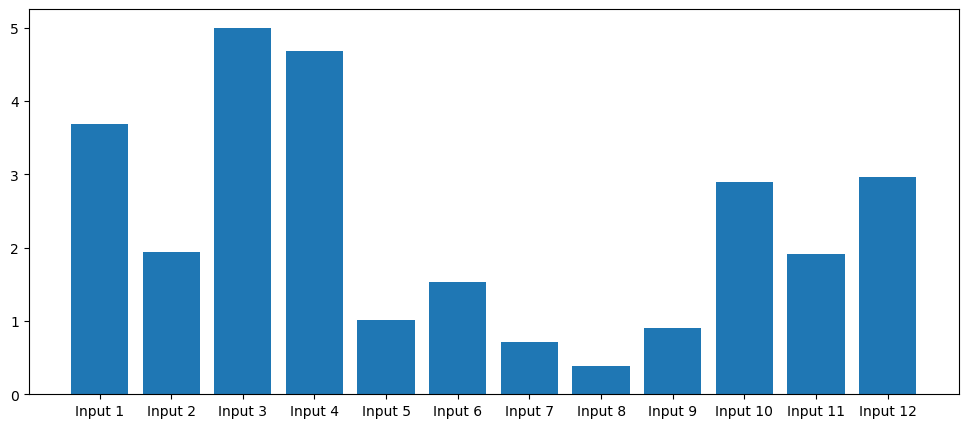

In [8]:
# get column names
columns = df.columns.tolist()

# exclude last column (class) 
features = len(columns)-1
columns=columns[:features]

# get and print the mean values for all sensors
print('The mean values are: \n{}'.format(df.mean(numeric_only=True)))

# store mean values
mean_values=df[:].mean(numeric_only=True)

# plot the data with bar charts
plt.figure(figsize=(12, 5))
plt.bar(columns, mean_values)

# Show the plot
plt.show()

### <font color='green'/> Data Preprocessing

<b> 7) TO DO: Create Feature Matrix and Target Vector</b>

<b>"Features"</b> are also known as predictors, inputs, or attributes. The <b>"response"</b> is also known as the target, label, or output.

#### <font color='orange'/> <em> complete in cell below </em>

In [9]:
# Create the feature matrix and target vector from the Pandas data frame
# Feature matrix (2D with n features)
X=df[[ 'Input 1',  'Input 2', 'Input 3', 'Input 4','Input 5','Input 6','Input 7','Input 8','Input 9','Input 10','Input 11','Input 12']]
# Target vector (1D column vector)
y = df['class']

<b> 8) TO DO: Convert the features dataframe to a numpy array</b>

In [10]:
# Use the values property of the dataframe to cast the objects to numpy arrays
X = df[['Input 1',  'Input 2', 'Input 3', 'Input 4','Input 5','Input 6','Input 7','Input 8','Input 9','Input 10','Input 11','Input 12']].values
y = df['class'].values

<b> 9) TO DO: Label Encoding</b>

Transform the categoricl labels into integers using the scikit-learn encoder

<b> Enter your code in the cell below</b>

In [11]:
#import label encoder
from sklearn.preprocessing import LabelEncoder

#instantiate integer encoder
label_encoder = LabelEncoder()

# encode the class labels
y_encoded =label_encoder.fit_transform(y)


# print the categorical class labels we encoded (note the underscore!)
print(y_encoded)

# print a few encoded values using python slice
print(y_encoded[:5])

# printing shape
print('encoded shape:',y_encoded.shape)

[0 0 0 ... 2 2 2]
[0 0 0 0 0]
encoded shape: (1463,)


<b> 10) TO DO: Split the data into Training and Testing Sets</b>

Scikit learn contains a function called the <b>train_test_split </b>function that will randomly shuffle the dataset and then splits it into two datasets: a <b>training set</b> used to build the model and a <b>test set</b> to assess and evaluate how well the model works on unseen data (also called out-of=sample data)


<em>**Use a 80% / 20% train/test split for this project.**</em>

Note: You **must** use the encoded class labels in this part

<b> Enter your code in the cell below</b>

In [12]:
from sklearn.model_selection import train_test_split

# test_size=0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

<b> 11) TO DO: Look at the <em>shape</em> of the data (rows and columns) <em>after</em> splitting it into training and testing sets</b>

<b> Enter your code in the next TWO cells below</b>

In [13]:
# examine the training and test data 
print ('X_train.shape:{}'.format(X_train.shape))
print ('y_train.shape:{}'.format(y_train.shape))

X_train.shape:(1170, 12)
y_train.shape:(1170,)


In [14]:
print ('X_test.shape:{}'.format(X_test.shape))
print ('y_test.shape:{}'.format(y_test.shape))

X_test.shape:(293, 12)
y_test.shape:(293,)


### <font color='green'/> Scale the Data

### <font color='red'/> IMPORTANT: Standardizing the features:

Standardization of datasets (feature scaling) is a common requirement for many machine learning and optimization algorithms implemented in
scikit-learn; they might behave badly if the individual features do not more or less look like standard normally distributed data, i.e., Gaussian with zero mean and unit variance.

<b> 12) TO DO: Let's use the StandarScaler from Scikit-learn to transform (<em>scale</em>) our feature</b>

<b> Enter your code in the cell below</b>

In [15]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

<b>A comment on what the above code does</b>
- Using the preceding code, we loaded the StandardScaler class from the preprocessing module and initialized a new StandardScaler object that we assigned to the variable sc.
- Using the fit method, StandardScaler estimated the parameters μ (sample mean) and 𝜎 (standard deviation) for each feature dimension from the training data.
- By calling the transform method, we then standardized the training data using those estimated parameters μ and 𝜎.
- Note that we used the same scaling parameters to standardize the test set so that both the values in the training and test dataset are comparable to each other.

<b>IMPORTANT: So from this point forward you must use the scaled training and testing data</b>

### <font color='green'/> Model Building

<b>Train multiple Machine Learning models during same session. You will use the three algorithms from previous labs.</b>
1. K-Nearest Neighbor (with K=10, K=50, K=200)
2. Logistic Regression
3. Linear Support Vector Classifier

During the evaluation phase you must predict class member propbabilities and comment on what they mean.This means that scikit-learn’s linear support vector classifier cannot be used for those prodictions since this model does not have a method to predict class membership probabilities, but like the other models, it does have the same *predict* method. 
- You MUST properly use model evaluation metrics (accuracy, confusion matrix, etc.)
- Two of your models (KNN and Logistic Regression MUST predict class membership probabilities and associated class label names


### <font color='green'/> Build a KNN Classification Model for K = 10, 50, and 200
<b>13) TO DO: In the sections below you should build and train the actual machine learning model.</b>

<b>In the cell below: enter the code to import, instantiate, fit, predict and test the model's performance (accuracy) for the K-Nearest Neighbor Model in SciKit-Learn for K= 10, 50 and 200.</b> *This should be completed in ONE cell using a loop, etc.*

In [16]:
#import
# model selection process
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics 
import warnings
warnings.filterwarnings("ignore")
# pick K-nearest neighbors
# instantiate
for k in [10,50,200]:
    knn = KNeighborsClassifier(n_neighbors=k)
    print(knn)
    knn.fit(X_train_std,y_train)
    y_pred = knn.predict(X_test_std)

# test the model's performance(accuracy)
    print('Test accuracy (using knn.score()) for k = {0} is: {1:0.2f}'.format(k,knn.score(X_test_std, y_test)))
    print("Model's Predictive Accuracy for k = {0} is:{1:.2f}".format(k,metrics.accuracy_score(y_test,y_pred)))
    print('Misclassified samples for k = {0} are {1}\n'.format(k,(y_pred != y_test).sum()))

# classifier is equal to knn for fitting
    classifier = knn

KNeighborsClassifier(n_neighbors=10)
Test accuracy (using knn.score()) for k = 10 is: 0.99
Model's Predictive Accuracy for k = 10 is:0.99
Misclassified samples for k = 10 are 4

KNeighborsClassifier(n_neighbors=50)
Test accuracy (using knn.score()) for k = 50 is: 0.96
Model's Predictive Accuracy for k = 50 is:0.96
Misclassified samples for k = 50 are 12

KNeighborsClassifier(n_neighbors=200)
Test accuracy (using knn.score()) for k = 200 is: 0.83
Model's Predictive Accuracy for k = 200 is:0.83
Misclassified samples for k = 200 are 51



<b> Predicting class-membership probabilities</b>

Scikit-Learn has a method that allows prediction of class member probabilities.
- The probability that training examples belong to a certain class can be computed using the predict_proba method. For example, we can predict the probabilities of the first three samples in the test set as follows (NOTE: X_test_std[:3. :] means get the first 3 rows and the associated columns from the test dataset X_test):
            
>classifier.predict_proba(X_test_std[:3, :]) where classifier is either **K-NN or Logistic Regression**


In the cells below, your must predict the **class-membership probabilities** for each specified **SINGLE ROW OF DATA**

Also, you should recall that the label encoding that we implemented earlier resulted in the mapping:

**class membership label indices after encoding**

       0 = 'one' (the Substance is Substance 1)
       1 = 'three' (false alarm)
       2 = 'two' (The Substance is Substance 2)

<b>14) TO DO: class-membership probability</b>

Predict the class membership probability by using the a row with **index = 10** from the X_test_std data. Make sure your print statement uses a complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

<b>Enter your code in the cell below.</b>

In [17]:
# reshaped the array
predicted_proba = classifier.predict_proba(X_test_std[10].reshape(1,-1))
predicted_class = classifier.predict(X_test_std[10].reshape(1,-1))


print("For a row with index = 10, the predicted class-membership probabilities are:", predicted_proba[0])
print("The predicted class for a row with index = 10 is:", predicted_class[0])
print("The actual class-memberships are:", y_test[10])

For a row with index = 10, the predicted class-membership probabilities are: [0.985 0.    0.015]
The predicted class for a row with index = 10 is: one
The actual class-memberships are: one


<b>15) TO DO:class-membership probability</b>

Predict the class membership probability by using the a row with **index = 125** from the X_test_std data. Make sure your print statement uses a complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

<b>Enter your code in the cell below.</b>

In [18]:
# reshaped the array
predicted_proba = classifier.predict_proba(X_test_std[125].reshape(1,-1))
predicted_class = classifier.predict(X_test_std[125].reshape(1,-1))


print("For a row with index = 125, the predicted class-membership probabilities are:", predicted_proba[0])
print("The predicted class for a row with index = 125 is:", predicted_class[0])
print("The actual class-memberships are:", y_test[125])

For a row with index = 125, the predicted class-membership probabilities are: [0.975 0.    0.025]
The predicted class for a row with index = 125 is: one
The actual class-memberships are: one


<b>16) TO DO:class-membership probability</b>

Predict the class membership probability by using the a row with **index = 200** from the X_test_std data. Make sure your print statement uses a complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

<b>Enter your code in the cell below.</b>

In [19]:
# reshaped the array
predicted_proba = classifier.predict_proba(X_test_std[200].reshape(1,-1))
predicted_class = classifier.predict(X_test_std[200].reshape(1,-1))


print("For a row with index = 200, the predicted class-membership probabilities are:", predicted_proba[0])
print("The predicted class for a row with index = 200 is:", predicted_class[0])
print("The actual class-memberships are:", y_test[200])

For a row with index = 200, the predicted class-membership probabilities are: [0.05 0.   0.95]
The predicted class for a row with index = 200 is: two
The actual class-memberships are: two


### <font color='green'/> Build Logistic Regression Model

<b>17) TO DO: scikit-learn Logistic Regression for this lab</b>

**Import and instantiate the *Logistic Regression* Model in SciKit-Learn is in the cell below**

In [20]:
# import logistic regression model
from sklearn.linear_model import LogisticRegression
# instantiate logistic regression model
lr = LogisticRegression(solver='newton-cg',
                        multi_class = 'multinomial',
                       random_state = 0)

<b>18) TO DO: Train the model by calling the model's fit function</b>

Now that the model has been instantiated (created) it still needs to be trained (*fitted*) to the training dataset. **Enter your code below to fit the model to the training dataset**

In [21]:
# X and y train were fit to logistic regression
lr.fit(X_train_std, y_train)

LogisticRegression(multi_class='multinomial', random_state=0,
                   solver='newton-cg')

<b>19) TO DO: Evaluate the Logistic Regression Model</b>

Use the test set to create the model's predictions. Name the prediction vector **y_pred** as in previous notebooks.

**Enter your code in the cell below:**

In [22]:
#displaying model's predictions
y_pred = lr.predict(X_test_std)
print("Test set predictions:\n {}".format(y_pred))

Test set predictions:
 ['two' 'one' 'one' 'one' 'one' 'one' 'two' 'three' 'three' 'one' 'one'
 'three' 'three' 'two' 'one' 'three' 'three' 'one' 'two' 'two' 'three'
 'one' 'one' 'two' 'one' 'three' 'one' 'three' 'three' 'two' 'two' 'two'
 'two' 'two' 'three' 'one' 'one' 'one' 'one' 'one' 'one' 'three' 'three'
 'two' 'one' 'one' 'one' 'three' 'two' 'one' 'one' 'three' 'one' 'one'
 'three' 'one' 'two' 'two' 'two' 'one' 'one' 'one' 'three' 'three' 'three'
 'one' 'two' 'two' 'two' 'three' 'two' 'three' 'two' 'two' 'two' 'two'
 'one' 'one' 'one' 'two' 'one' 'three' 'three' 'one' 'one' 'two' 'two'
 'one' 'three' 'one' 'two' 'two' 'one' 'two' 'two' 'two' 'two' 'three'
 'one' 'one' 'one' 'one' 'two' 'one' 'two' 'one' 'three' 'two' 'three'
 'three' 'one' 'one' 'one' 'two' 'two' 'two' 'three' 'one' 'one' 'one'
 'three' 'one' 'three' 'one' 'three' 'one' 'one' 'three' 'one' 'two' 'two'
 'one' 'one' 'one' 'one' 'three' 'three' 'two' 'three' 'one' 'two' 'three'
 'one' 'two' 'three' 'three' 'three' '

**20) TO DO: Evaluate the Logistic Regression Model's Performance**

Use SciKit Learn's built-in scoring method to evaluate the model's performance accuracy.

**Enter your code below:**

In [23]:
# model's accuracy
print('Test accuracy: {0:0.2f}'.format(lr.score(X_test_std, y_test)))

Test accuracy: 0.98


**Predicting class-membership probabilities using the Logistic Regression Model**

**21) TO DO: class-membership probability**

Predict the class membership probability by using the a row with **index = 10** from the X_test_std data. Make sure your print statement uses a complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

**Enter your code in the cell below.**

In [24]:
# predicted probability 
print('The predicted probability for index = {} is {}'
      .format(10, lr.predict_proba(X_test_std[10].reshape(1,-1))))
print("The actual class-memberships:", y_test[10])

The predicted probability for index = 10 is [[1. 0. 0.]]
The actual class-memberships: one


**22) TO DO:class-membership probability**

Predict the class membership probability by using the a row with **index = 130** from the X_test_std data. Make sure your print statement uses a complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

**Enter your code in the cell below.**

In [25]:
# predicted probability 
print('The predicted probability for index = {} is {}'
      .format(125, lr.predict_proba(X_test_std[125].reshape(1,-1))))
print("The actual class-memberships:", y_test[125])

The predicted probability for index = 125 is [[1. 0. 0.]]
The actual class-memberships: one


**23) TO DO: class-membership probability**

Predict the class membership probability by using the a row with **index = 200** from the X_test_std data. Make sure your print statement uses a complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

**Enter your code in the cell below.**

In [26]:
# predicted probability 
print('The predicted probability for index = {} is {}'
      .format(200, lr.predict_proba(X_test_std[200].reshape(1,-1))))
print("The actual class-memberships:", y_test[200])

The predicted probability for index = 200 is [[0.003 0.    0.997]]
The actual class-memberships: two


### <font color='green'/> Build Linear Support Vector Classifier Model

**24) TO DO:scikit-learn Linear Support Vector Classifier for this lab**

**Import and instantiate the *Linear Support Vector Classifier* Model in SciKit-Learn is in the cell below**

In [27]:
# Fitting the model using a Linear Support Vector Machine Classifier
from sklearn.svm import LinearSVC
import warnings
warnings.filterwarnings("ignore")
# Instantiate the model 
lsvc=LinearSVC()

**25) TO DO: Train the model by calling the model's fit function**

Now that the model has been instantiated (created) it still needs to be trained (*fitted*) to the training dataset. **Enter your code below to fit the model to the training dataset**

In [28]:
# fit the data 
lsvc.fit(X_train_std, y_train)

LinearSVC()

**26) TO DO: Evaluate the Linear Suport Vector Classifier Model**

Use the test set to create the model's predictions. Name the prediction vector **y_pred** as in previous notebooks.

**Enter your code in the cell below:**

In [29]:
# Let's Evaluate the Support Vector Machine Model 
y_pred = lsvc.predict(X_test_std)
print("Test set predictions: {}".format (y_pred))

Test set predictions: ['two' 'one' 'one' 'one' 'one' 'one' 'two' 'three' 'three' 'one' 'one'
 'three' 'three' 'two' 'one' 'three' 'three' 'one' 'two' 'two' 'three'
 'one' 'one' 'two' 'one' 'three' 'one' 'three' 'three' 'two' 'two' 'two'
 'two' 'two' 'three' 'one' 'one' 'one' 'one' 'one' 'one' 'three' 'three'
 'two' 'one' 'one' 'one' 'three' 'two' 'one' 'one' 'three' 'one' 'one'
 'three' 'one' 'two' 'two' 'two' 'one' 'one' 'one' 'three' 'three' 'three'
 'one' 'two' 'two' 'two' 'three' 'two' 'three' 'two' 'two' 'two' 'two'
 'one' 'one' 'one' 'two' 'one' 'three' 'three' 'one' 'one' 'two' 'two'
 'one' 'three' 'one' 'two' 'two' 'one' 'two' 'two' 'two' 'two' 'three'
 'one' 'one' 'one' 'one' 'two' 'one' 'two' 'one' 'three' 'two' 'three'
 'three' 'one' 'one' 'one' 'two' 'two' 'two' 'three' 'one' 'one' 'one'
 'three' 'one' 'three' 'one' 'three' 'one' 'one' 'three' 'one' 'two' 'two'
 'one' 'one' 'one' 'one' 'three' 'three' 'two' 'three' 'one' 'two' 'three'
 'one' 'two' 'three' 'three' 'three' 't

**27) TO DO: Evaluate the Linear Suport Vector Model's Performance**

Use SciKit Learn's built-in scoring method to evaluate the model's performance accuracy.

**Enter your code below:**

In [30]:
# model's accuracy
print('Test accuracy: {0:0.2f}'.format(lr.score(X_test_std, y_test)))

Test accuracy: 0.98


**28) TO DO: Using the Predict Method of the Linear Suport Vector Model**

Use SciKit Learn's built-in *predict method* to test the model's predictive performance for the first row of data in X_test_std

**Enter your code below:**

In [31]:
# Predicting for the first row of X_test
first_row = X_test_std[0].reshape(1, -1)  # Reshape the first row to match the expected input shape

# Predict using the trained model
prediction = lsvc.predict(first_row)

# Print the prediction
print("Predicted class label:", prediction)


Predicted class label: ['two']


**29) TO DO:Print the number of misclassifications using numpy**

In [32]:
print(f'Misclassified samples are: {(y_pred != y_test).sum()}\n')

Misclassified samples are: 8



### <font color='green'/>Confusion Matrix
Supervised learner models are designed to classify, estimate, and/or predict future outcome. For some applications the desire is to build models showing consistently high predictive accuracy.

**Classification Correctness:**

Classification correctness is best calculated by presenting previously unseen data in the form of a test set to the model being evaluated. Test set model accuracy can be summarized in a table known as a confusion matrix. To illustrate, let’s suppose we have three possible classes: C1,
C2, and C3. A generic confusion matrix for the three class case is shown in Table 1.

- Values along the main diagonal give the total number of correct classifications for each class.
>For example, a value of 15 for C11 means that 15 class C1 test set instances were correctly classified.

- Values other than those on the main diagonal represent classification errors.
>To illustrate, suppose C12 has the value 4. This means that four class C1 instances were incorrectly classified as
belonging to class C2. The following three rules may be helpful in analyzing the information in a confusion matrix:

**Rules for the Three-Class Confusion Matrix**
- Rule 1. Values along the main diagonal represent correct classifications. For the matrix in Table 1,the value C11 represents the total number of class C1 instances correctly classified by the model. A similar statement can be made for the values C22 and C33.
- Rule 2. Values in row Ci represent those instances that belong to class Ci. For example, with i = 2,the instances associated with cells C21, C22, and C23 are all actually members of C2. To find the total number of C2 instances incorrectly classified as members of another class, we compute the sum of C21 and C23.
- Rule 3. Values found in column Ci indicate those instances that have been classified as members of Ci. With i = 2,the instances associated with cells C12, C22, and C32 have been classified as members of class C2.To find the total number of instances incorrectly classified as members of class C2, we compute the sum of C12 and C32.

**30) TO DO: Compute the Confusion Matrix for the Linear Suport Vector Model**

Use SciKit Learn's metrics module to compute the model's confusion matrix.

**Enter your code below:**

Confusion Matrix:
[[128   0   3]
 [  0  75   2]
 [  3   0  82]]


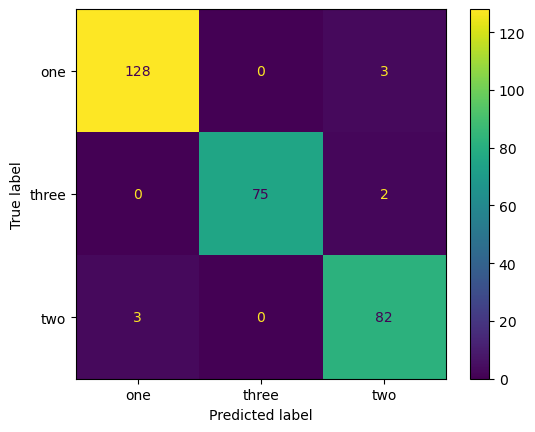

In [33]:
# Confusion Matrix 
from sklearn import metrics 
print("Confusion Matrix:")
print(metrics.confusion_matrix(y_test, y_pred))


import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=lsvc.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lsvc.classes_)
disp.plot()
plt.show()

**31)TO DO: Classification Correctness**

Based on the output of your **confusion matrix**, what was the total number of *correct* classifications of Substance 2?

**Enter your answer as markdown in the cell below:**

82 correct classifications

**32) TO DO: Compute the Classification report for Linear Suport Vector Model**

Use SciKit Learn's metrics module to compute the model's classification report.

**Enter your code below:**

In [34]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

         one       0.98      0.98      0.98       131
       three       1.00      0.97      0.99        77
         two       0.94      0.96      0.95        85

    accuracy                           0.97       293
   macro avg       0.97      0.97      0.97       293
weighted avg       0.97      0.97      0.97       293



**33) TO DO: Classification Report**

Based on the output of your **classification report**, out of all the times Substance 1 should have been predicted, what percentage of times was it correctly predicted?

Which performance score did you use to evaluate the performance of the model(s) from the confusion matrix /classification report? (HINT: You may need to research the meaning and difference between precision, recall and f1-score)

**Enter your answer as markdown in the cell below:**

The percentage of time that Substance 1 was correctly predicted was 98%. After looking up the definitions of precision, recall, and f1-score, I looked at the precision scores.  

Precision represents the proportion of true positive predictions among all instances predicted as a particular class. Specifically, for Substance 1, the precision of 0.98 indicates that out of all the times Substance 1 was predicted by the model, 98% of the predictions were correct.

Therefore, the model correctly predicted Substance 1 approximately 98% of the time.

### <font color='green'/>Serialization

#### <font color='purple'/>34) TO DO: Model Persistence - Save/Load the trained classifier

To receive full credit for this part you *must test the saved and re-loaded classifiers on an instance of “unknown” data and show that it correctly classifies the instance*. It’s ok if you use an instance (sample) that is from the test set as the “unknown” data.

#### <font color='purple'/>NOTE: Use *either* the Logistic Regression Model or the K-Nearest Neighbors Classifier for this part

### Step1: Save the model

**Pickle (serialize) and save the trained classifier to a folder**

**Enter your code below:**

In [35]:
# assign classifier to serialize 
saved_classifier = lsvc
# serialization with python's pickle
import pickle
import os

dest = os.path.join('classifier','pkl_objects')
if not os.path.exists(dest):
    os.makedirs(dest)
    
pickle.dump(saved_classifier, open(os.path.join(dest,'classifier.pkl'),'wb'),protocol=4)

### Step 2: Load the saved model

**Load the saved the trained classifier into memory**

**Enter your code below:**

In [36]:
# load the saved the trained classifier into memory 
import pickle
import re
import os
os.chdir('classifier')
classifier_reloaded = pickle.load(open(os.path.join('pkl_objects','classifier.pkl'),'rb'))

### Step 3: Test the re-loaded model

**Use SciKit Learn's built-in predict method to test the re-loaded model on data from the row of data in X_test_std with index equal to six (6)**

**Enter your code below:**

In [37]:
# Test on the row with index = 6
row_index = 6
first_row = X_test_std[row_index].reshape(1, -1) 

# Predict using the re-loaded model
prediction = classifier_reloaded.predict(first_row)

print("Predicted class label:", prediction)

Predicted class label: ['two']


*Give a brief (¼ page) report (in the markdown cell below ) of your analysis detailing your understanding of the analysis, the machine learning models and their comparative performance, statistical insights, etc. (include reference website links if used).*

>#### <font color='orange'/>Answer in the cell below

In this analysis, we compared the performance of logistic regression, K-nearest neighbors (KNN), and Linear Support Vector Machine (SVM) models on a dataset with standardized features and class labels. All three models achieved high accuracy, with logistic regression and KNN models reaching 97% accuracy, and the Linear SVM model also achieving a comparable level of accuracy. The logistic regression model exhibited slightly higher precision and recall for some classes, while the KNN and Linear SVM models showed comparable performance across all classes.
Overall, there was no significant difference in performance between the models. The choice between these models depends on factors such as the nature of the data, interpretability of the model, and computational efficiency. Logistic regression makes strong assumptions about the data distribution, KNN is a non-parametric model making no assumptions, and Linear SVM aims to find the optimal hyperplane to separate classes. All three models demonstrated effective performance in classifying instances, and the choice between them depends on the specific characteristics of the data and the requirements of the problem at hand.

#### <font color='red'/>BONUS (15pts)

<font color='blue'/>It is **your choice** to do the bonus or not. It can only add points to your total course grade. It wont't hurt your grade if you chose NOT to do it.
BUT, if you are going to attempt it, do it in the cells below (add cells as necessary). Follow the instructions for the notebook cells layout *exactly* as indicated in the bonus document or you may not receive credit!

### Model Performance Comparision of two Classifiers

Using the **logistic regression model** and the **KNN model** (do NOT re-instantiate and re-train the model. Use the last knn model from your previous section), compare the performance of the models using the above statistic when we only have one test set. To to this you need to calculate (**and print**) in individual notebook cells the following:

$E_1$ : the error rate for model $M_1$, your K-Nearest Neighbor Model

**Enter your code below:**

In [38]:
E1 = 1 - knn.score(X_test_std, y_test)
print(E1)

0.174061433447099


$E_2$ is the error rate for model $M_2$, your Logistic Regression Model

**Enter your code below:**

In [39]:
#error rate is 1-accuracy
E2 = 1 - lr.score(X_test_std, y_test)
print(E2)

0.023890784982935176


$ q $ = $\frac{(E_1 + E_2)}{2}$ ,  the error rate average

**Enter your code below:**

In [40]:
q = (E1 + E2)/2

print("The error rate average is {}".format(q))

The error rate average is 0.0989761092150171


$n_1$, the number of instances in test set A

**Enter your code below:**

In [41]:
n1 = len(y_test)
print("The number of instances in test set A is: {}".format(n1))

The number of instances in test set A is: 293


$n_2$, the number of instances in test set B

**Enter your code below:**

In [42]:
n2 = n1
print("The number of instances in test set B is: {}".format(n2))

The number of instances in test set B is: 293


####  <font color='orange'/>*Using Python, write a simple decision construct to compute and display $P$, depending on whether $P$ &ge; 2. Use a complete sentence in your output.*

In [43]:
import math

P = (abs(E1 - E2)) / (math.sqrt(q * (1 - q) * (2 / n1)))

if P >= 2:
    print("The P-value is: {}".format(P))
    print("P-value is greater than or equal to 2, so we are 95% confident that the difference between the two different models' performance is statistically significant.")
else:
    print("The P-value is: {}".format(P))
    print("P is less than 2, therefore, we cannot say that the difference between the two different models' performance is statistically significant.")

The P-value is: 6.08654064403535
P-value is greater than or equal to 2, so we are 95% confident that the difference between the two different models' performance is statistically significant.


<center>
    <h3><font color='red'>End of Project</font></h3>
</center>